### Analysis on Trader Historical Hyperliquid data and Feer & Greed Index Classified data

#### Input: 2 Data Sets  
#### Goal: Understand How market sentiment  affects trader performance on Hyperliquid.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import seaborn as sns
from scipy import stats

In [47]:
# Global Color palette & plot style

# SENTIMENT_COLORS = {
#     'Extreme Fear' :  '#ff1900',
#     'Fear'         : '#e74c3c',
#     'Neutral'      : '#f39c12',
#     'Greed'        : '#27ae60',
#     'Extreme Greed': '#1abc9c',
# }

# sentiment palette (modern UI colors)
SENTIMENT_COLORS = {
    'Extreme Fear': '#d73027',
    'Fear': '#fc8d59',
    'Neutral': '#91a1b0',
    'Greed': '#66bd63',
    'Extreme Greed': '#1a9850'
}

SENT_ORDER = ['Extreme Fear', 'Fear','Neutral', 'Greed', 'Extreme Greed']
SENT_PAL = [SENTIMENT_COLORS[s] for s in SENT_ORDER]

plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#e6edf3',
    'xtick.color'      : '#e6edf3',
    'ytick.color'      : '#e6edf3',
    'text.color'       : '#e6edf3',
    'grid.color'       : '#21262d',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
})


In [3]:
# Load The Datasets
Trader_Logs = 'historical_data.csv'
Fear_class = 'fear_greed_index.csv'

In [4]:
trader = pd.read_csv(Trader_Logs, parse_dates=['Timestamp IST'])
fear_greed = pd.read_csv(Fear_class, parse_dates=['date'])

Data Pre Processing

In [5]:
# Normalize the Column names
trader.columns = trader.columns.str.lower().str.strip()
fear_greed.columns = fear_greed.columns.str.lower().str.strip()

In [6]:
trader.columns

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')

In [7]:
fear_greed.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [8]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   account           211224 non-null  object 
 1   coin              211224 non-null  object 
 2   execution price   211224 non-null  float64
 3   size tokens       211224 non-null  float64
 4   size usd          211224 non-null  float64
 5   side              211224 non-null  object 
 6   timestamp ist     211224 non-null  object 
 7   start position    211224 non-null  float64
 8   direction         211224 non-null  object 
 9   closed pnl        211224 non-null  float64
 10  transaction hash  211224 non-null  object 
 11  order id          211224 non-null  int64  
 12  crossed           211224 non-null  bool   
 13  fee               211224 non-null  float64
 14  trade id          211224 non-null  float64
 15  timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [9]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


Before we do Merging we need get the granularity between two datasets our candidate keys are of different datatypes, we need to handle then:
1. Converting Timestamp IST -> datetime and extract the date init
2. and use the trader[date] and fear_greed[date] to merge the datasets

In [10]:
trader.columns

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')

In [11]:
# Convert to datetime
trader['timestamp ist'] = pd.to_datetime(trader['timestamp ist'],dayfirst=True)

# Extract date
# trader['date'] =  trader['Timestamp IST'].dt.date
trader['date'] = trader['timestamp ist'].dt.normalize()

In [12]:
trader['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 211224 entries, 0 to 211223
Series name: date
Non-Null Count   Dtype         
--------------   -----         
211224 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.6 MB


In [13]:
# Merge the datasets to on date
merged_df = trader.merge(fear_greed[['value', 'classification', 'date']], on = 'date', how = 'left').rename(columns={'classification': 'sentiment'})

In [14]:
merged_df.head()

,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp,date,value,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [15]:
merged_df.shape

(211224, 19)

In [16]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   account           211224 non-null  object        
 1   coin              211224 non-null  object        
 2   execution price   211224 non-null  float64       
 3   size tokens       211224 non-null  float64       
 4   size usd          211224 non-null  float64       
 5   side              211224 non-null  object        
 6   timestamp ist     211224 non-null  datetime64[ns]
 7   start position    211224 non-null  float64       
 8   direction         211224 non-null  object        
 9   closed pnl        211224 non-null  float64       
 10  transaction hash  211224 non-null  object        
 11  order id          211224 non-null  int64         
 12  crossed           211224 non-null  bool          
 13  fee               211224 non-null  float64       
 14  trad

In [17]:
df = merged_df.copy()

In [18]:
# We have 6 missing values within value and sentiment -> forward fill
df['value'] = df['value'].ffill()
df['sentiment'] = df['sentiment'].ffill()

In [19]:
# df.isnull().sum()

In [20]:
# df.info() # filled the missing value

In [21]:
# Check for Duplicates
df = df.drop_duplicates(subset=['trade id'])

In [22]:
# Standardze the texts
df['side'] = df['side'].str.upper().str.strip()
df['direction'] = df['direction'].str.upper().str.strip()

In [23]:
# categorize the Sentiment column
df.loc[:, 'sentiment'] = pd.Categorical(
    df['sentiment'],
    categories=SENT_ORDER,
    ordered=True
)

### Feature Derivation

In [24]:
# Time based
df['hour'] = df['timestamp ist'].dt.hour
df['dow'] = df['timestamp ist'].dt.day_name()
df['month'] = df['timestamp ist'].dt.to_period('M').astype(str)

In [25]:
# Trade outcome
df['is_winner'] = df['closed pnl'] > 0
df['is_long'] = df['side'] == 'BUY'

In [33]:
# Notional
df['notional'] = df['size tokens'] * df['execution price']

# Position value
df['position_value'] = df['start position'].abs() * df['execution price']

# Leverage proxy
df['leverage_proxy'] = np.where(
    df['position_value'] > 0,
    (df['size usd'].abs() / df['position_value']).clip(1,100),
    np.nan
)

df['leverage_proxy'] = df['leverage_proxy'].fillna(1)

# Risk adjusted exposure
df['risk_adj'] = df['notional'] * df['leverage_proxy']

# Rolling win rate
df = df.sort_values(['account','timestamp ist'])

df['rolling_wr'] = (
    df.groupby('account')['is_winner']
      .transform(lambda x: x.rolling(20, min_periods=5).mean())
      .fillna(0.5)
)

In [27]:
# # Rolling 20 trade win rate per account
# df = df.sort_values(['account', 'timestamp ist'])
# df['rolling_wr'] = (
#     df.groupby('account')['is_winner']
#            .transform(lambda x: x.rolling(20, min_periods=5).mean())
# )


In [34]:
df[df['position_value'] == 0].shape

(54, 29)

In [36]:
df[['timestamp ist','side','direction','closed pnl','is_winner','is_long',
               'size usd','notional','leverage_proxy','risk_adj']].head(5)

,timestamp ist,side,direction,closed pnl,is_winner,is_long,size usd,notional,leverage_proxy,risk_adj
14252,2024-11-11 08:28:00,SELL,OPEN SHORT,0.0,False,False,2522.92,2522.9158,1.0,2522.9158
14286,2024-11-11 08:40:00,SELL,OPEN SHORT,0.0,False,False,3203.00,3203.0000,1.0,3203.0000
14351,2024-11-11 08:41:00,SELL,OPEN SHORT,0.0,False,False,30000.58,30000.5792,1.0,30000.5792
14372,2024-11-11 08:41:00,SELL,OPEN SHORT,0.0,False,False,4878.17,4878.1690,1.0,4878.1690
14376,2024-11-11 08:41:00,SELL,OPEN SHORT,0.0,False,False,1047.70,1047.7013,1.0,1047.7013


In [35]:
df.isnull().sum()

account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
date                0
value               0
sentiment           0
hour                0
dow                 0
month               0
is_winner           0
is_long             0
notional            0
position_value      0
leverage_proxy      0
risk_adj            0
rolling_wr          0
dtype: int64

# Sentiment Distribution

In [38]:
fear_greed.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

#### Understanding sentiment data.
Data has classification of fear and greed by days which indicates the trader's behavior each day when they make decisions.
- Fear vs Greed Distribution per days
- Time Series -> what does the index

In [40]:
# How many days per sentiment label?
sent_counts = (
    fear_greed['classification'].value_counts().reindex(SENT_ORDER).dropna())

print('Days per sentiment regime')
print(sent_counts)
print(f'\n Total days: {sent_counts.sum()}')

Days per sentiment regime
classification
Extreme Fear     508
Fear             781
Neutral          396
Greed            633
Extreme Greed    326
Name: count, dtype: int64

 Total days: 2644


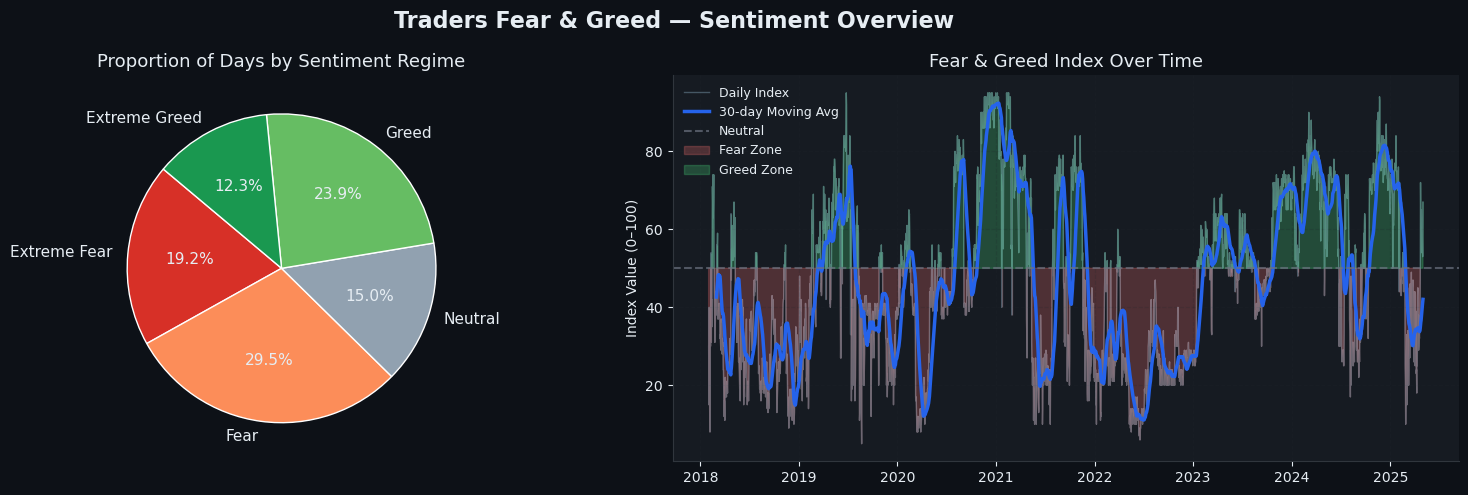

In [48]:
import matplotlib.pyplot as plt



fig, axes = plt.subplots(1,2, figsize=(16,5))

fig.suptitle(
    'Traders Fear & Greed — Sentiment Overview',
    fontsize=16,
    fontweight='bold'
)

# ---------------- PIE CHART ----------------
axes[0].pie(
    sent_counts.values,
    labels=sent_counts.index,
    colors=[SENTIMENT_COLORS[s] for s in sent_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':1},
    textprops={'fontsize':11}
)

axes[0].set_title(
    'Proportion of Days by Sentiment Regime',
    fontsize=13
)


# ---------------- TIME SERIES ----------------
fg_sorted = fear_greed.sort_values('date').copy()
fg_sorted['roll30'] = fg_sorted['value'].rolling(30).mean()

# daily line
axes[1].plot(
    fg_sorted['date'],
    fg_sorted['value'],
    alpha=0.35,
    color='#9ecae1',
    linewidth=1,
    label='Daily Index'
)

# rolling mean
axes[1].plot(
    fg_sorted['date'],
    fg_sorted['roll30'],
    color='#2563eb',
    linewidth=2.5,
    label='30-day Moving Avg'
)

# neutral line
axes[1].axhline(
    50,
    color='#6b7280',
    linestyle='--',
    alpha=0.7,
    label='Neutral'
)

# fear zone
axes[1].fill_between(
    fg_sorted['date'],
    fg_sorted['value'],
    50,
    where=fg_sorted['value'] < 50,
    color='#f87171',
    alpha=0.25,
    label='Fear Zone'
)

# greed zone
axes[1].fill_between(
    fg_sorted['date'],
    fg_sorted['value'],
    50,
    where=fg_sorted['value'] >= 50,
    color='#4ade80',
    alpha=0.25,
    label='Greed Zone'
)

axes[1].set_title(
    'Fear & Greed Index Over Time',
    fontsize=13
)

axes[1].set_ylabel('Index Value (0–100)')
axes[1].grid(alpha=0.2)
axes[1].legend(frameon=False, fontsize=9)

# remove top/right borders
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

--- 
### Pie Chart
The "Fear" Dominance: If you combine Fear (29.5%) and Extreme Fear (19.2%), traders spend nearly half their time (48.7%) feeling anxious or scared.  
Greed is Less Common: Traders spend about 36% of their time feeling greedy.  
The Neutral Middle: Only 15% of the time is the market "calm" or neutral.  

### Time Series
The "Fear Zone" (Red area below 50): When the blue line dips into the red, traders are scared. These often align with market crashes or periods of high uncertainty.  
The "Greed Zone" (Green area above 50): When the blue line stays in the green, traders are overly optimistic. These are usually "bull markets" where everyone is buying.  
Insight: Notice the sharp, frequent "spikes" and "dips." This tells you that trader sentiment is highly volatile—it swings from panic to excitement very quickly, rarely staying calm for long.  

In [50]:
# How many Tarde happened in each category/regime?
trade_counts = (
    df['sentiment'].value_counts().reindex(SENT_ORDER))

print('Number of trades per sentiment regime')
print(trade_counts)

Number of trades per sentiment regime
sentiment
Extreme Fear     235
Fear             866
Neutral          399
Greed            709
Extreme Greed    601
Name: count, dtype: int64


# PnL by Sentiment Regime

#### Here need to find-> do traders make or lose money depending on market sentiment?

In [52]:
sent_pnl = (
    df.groupby('sentiment', observed=True)['closed pnl']
    .agg(n_trades = 'count',
         mean_pnl = 'mean',
         median_pnl = 'median',
         std_pnl= 'std',
         total_pnl = 'sum'
        ).reindex(SENT_ORDER).dropna()
)
print('PnL statistics by sentiment regime:')
sent_pnl.style.format({
    'mean_pnl'  : '${:.2f}',
    'median_pnl': '${:.2f}',
    'total_pnl' : '${:,.0f}',
    'std_pnl'   : '${:.2f}',
})

PnL statistics by sentiment regime:


,n_trades,mean_pnl,median_pnl,std_pnl,total_pnl
sentiment,,,,,
Extreme Fear,235,$168.60,$0.00,$911.02,"$39,620"
Fear,866,$235.33,$0.00,$3173.37,"$203,793"
Neutral,399,$87.96,$0.00,$311.31,"$35,095"
Greed,709,$37.03,$0.00,$3377.38,"$26,253"
Extreme Greed,601,$56.96,$0.00,$304.25,"$34,235"


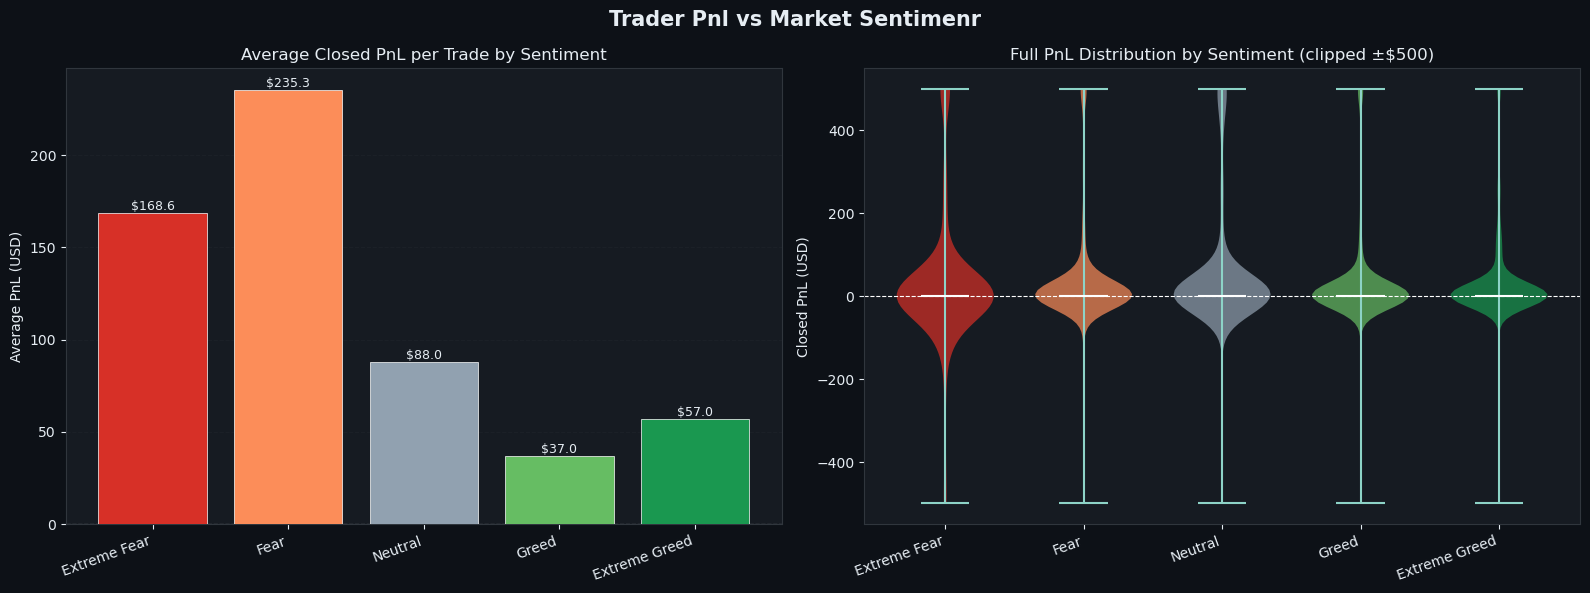

In [62]:
# bar chart to show avg PnL per Sentiment
fig, axes = plt.subplots(1,2, figsize=(16,6))
fig.suptitle('Trader Pnl vs Market Sentimenr', fontsize=15, fontweight = 'bold')

bars = axes[0].bar(
    range(len(sent_pnl)),sent_pnl['mean_pnl'], 
    color=[SENTIMENT_COLORS[s] for s in sent_pnl.index],
    edgecolor='white', linewidth=.5, zorder=3
)
axes[0].axhline(0, color='white', linewidth=.8, linestyle= '--')
axes[0].set_xticks(range(len(sent_pnl)))
axes[0].set_xticklabels(sent_pnl.index, rotation=20, ha='right')
axes[0].set_title('Average Closed PnL per Trade by Sentiment')
axes[0].set_ylabel('Average PnL (USD)')
axes[0].grid(axis='y', zorder=0)

for bar, val in zip(bars, sent_pnl['mean_pnl']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (1.5 if val >= 0 else -5),
                 f'${val:.1f}', ha='center', fontsize=9
                )

# Violin plot to see full PnL Distribution
violin_data = [
    df[df['sentiment'] == s]['closed pnl'].dropna().clip(-500, 500).values #cliping to ±500 so extreme outliers don't squash the chart
    for s in SENT_ORDER if s in df['sentiment'].values
]

parts = axes[1].violinplot(violin_data, positions=range(len(SENT_ORDER)), widths=.7, showmedians=True)

for pc, color in zip(parts['bodies'], SENT_PAL):
    pc.set_facecolor(color)
    pc.set_alpha(.7)
    
parts['cmedians'].set_color('white')
axes[1].set_xticks(range(len(SENT_ORDER)))
axes[1].set_xticklabels(SENT_ORDER, rotation=20, ha='right')
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title('Full PnL Distribution by Sentiment (clipped ±$500)')
axes[1].set_ylabel('Closed PnL (USD)')  

plt.tight_layout()
plt.show()

### The Bar Chart: Average Profit (PnL)

The Big Winner: "Fear" (Orange Bar) is the most profitable time to trade, with an average profit of $235.  

The Big Loser: "Greed" (Light Green Bar) is the least profitable, averaging only $37.

Insight: There is a massive drop in profit as the market moves from Fear to Greed. It suggests that when everyone else is "greedy" and buying, these traders are likely buying at the top and making very little profit.  

### The Violin Chart: The "Risk" View
This shows the distribution—or the "spread"—of wins and losses. Think of the "fat" part of each shape as where most trades land.  

Consistency: All the shapes are thickest around the 0 line (the white dotted line). This means most trades, regardless of mood, don't make or lose huge amounts of money.  

Fear is "Spiky": Notice the Extreme Fear (Red) and Fear (Orange) shapes have taller "necks" pointing upward. This confirms that while most trades are small, the "home run" big-money trades happen during fearful times.  

Greed is "Stable" but Small: The Greed (Green) shapes are much shorter and rounder. This means trades during greedy times are very "safe" but very small. There are almost no big breakout wins when the market is already greedy.  

# Win Rate Per Sentiment

Win Rate = %of tardes that were profitable
if winners are much bigger tahn losers risk:reward ratio

In [63]:
win_rate = (
    df.groupby('sentiment', observed = True)['is_winner']
    .agg(win_rate = 'mean', n_trades='count')
    .reindex(SENT_ORDER)
    .dropna()
)
# win rate percentage
win_rate['win_rate_pct'] = win_rate['win_rate'] * 100

print('Win rate by sentiment:')
win_rate[['win_rate_pct', 'n_trades']].style.format({'win_rate_pct': '{:.1f}%'})

Win rate by sentiment:


,win_rate_pct,n_trades
sentiment,,
Extreme Fear,30.6%,235
Fear,43.8%,866
Neutral,45.9%,399
Greed,33.0%,709
Extreme Greed,36.3%,601


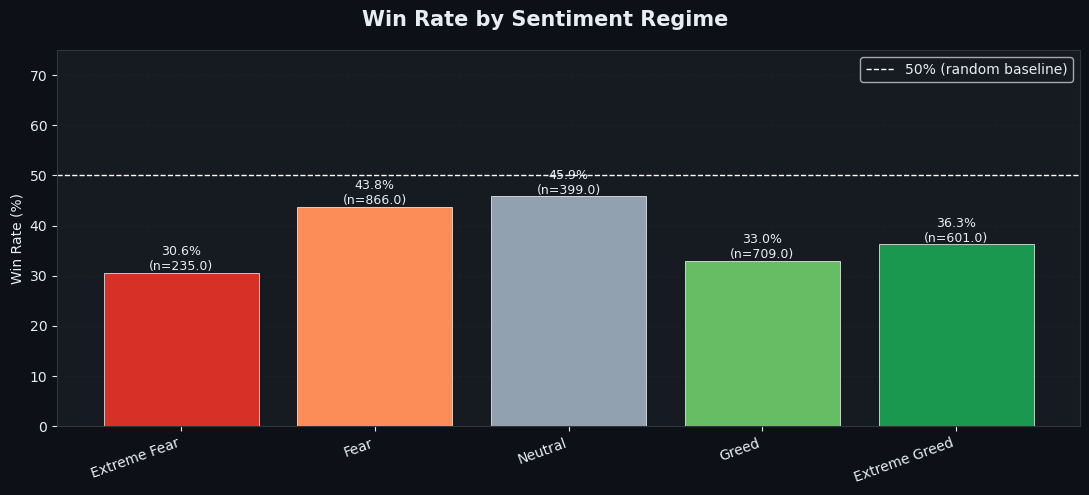

In [64]:
# bar chart 
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Win Rate by Sentiment Regime', fontsize=15, fontweight='bold')

bars = ax.bar(
    range(len(win_rate)),
    win_rate['win_rate_pct'],
    color=[SENTIMENT_COLORS[s] for s in win_rate.index],
    edgecolor='white', linewidth=0.5, zorder=3
)
ax.axhline(50, color='white', linestyle='--', linewidth=1, label='50% (random baseline)')
ax.set_xticks(range(len(win_rate)))
ax.set_xticklabels(win_rate.index, rotation=20, ha='right')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 75)
ax.legend()
ax.grid(axis='y', zorder=0)


for bar, (_, row) in zip(bars, win_rate.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{row['win_rate_pct']:.1f}%\n(n={row['n_trades']:,})",
        ha='center', fontsize=9
    )

plt.tight_layout()
plt.show()

Nobody is "Winning" Half the Time: The dotted line at 50% represents a coin flip (random luck). Notice that all the bars are below this line.  
This means that in every mood, traders are losing more often than they are winning.  
The Best Mood is "Neutral": Traders have their highest success rate (45.9%) when the market is calm and neutral (the gray bar).  
The Worst Mood is "Extreme Fear": When the market is in a total panic (the red bar), traders only win about 30% of the time. This is their "losing streak" zone.  
Greed is Harder than it Looks: Even when the market is "Greedy" (green bars), the win rate is still low (33% to 36%).  


# Long (Buying) /Short (selling) Directional Bias

During fear, are tarders mostly going long or short?  
does that directional choice pay off?  

This method reveals behavioural Bias -> do traders go against thier best interest when scared?

In [67]:
# df.head(2)

In [68]:
# Tarde direction count per sentiment

direction_counts = (
    df.groupby(['sentiment', 'side'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(SENT_ORDER)
    .dropna()
)
# to percentage

direction_pct = direction_counts.div(direction_counts.sum(axis=1), axis=0) * 100

print('Trade direction (% of trades per sentiment):')
direction_pct.style.format('{:.1f}%')


Trade direction (% of trades per sentiment):


side,BUY,SELL
sentiment,,
Extreme Fear,69.4%,30.6%
Fear,55.4%,44.6%
Neutral,49.6%,50.4%
Greed,39.5%,60.5%
Extreme Greed,41.1%,58.9%


In [70]:
#  Avg PnL: Long vs Short per sentiment
pnl_by_direction = (
    df.groupby(['sentiment', 'side'], observed=True)['closed pnl']
    .size()
    .unstack(fill_value=0)
    .reindex(SENT_ORDER)
    .dropna()
)
print('Average PnL per trade: Long vs Short by sentiment:')
pnl_by_direction.style.format('${:.2f}')

Average PnL per trade: Long vs Short by sentiment:


side,BUY,SELL
sentiment,,
Extreme Fear,$163.00,$72.00
Fear,$480.00,$386.00
Neutral,$198.00,$201.00
Greed,$280.00,$429.00
Extreme Greed,$247.00,$354.00


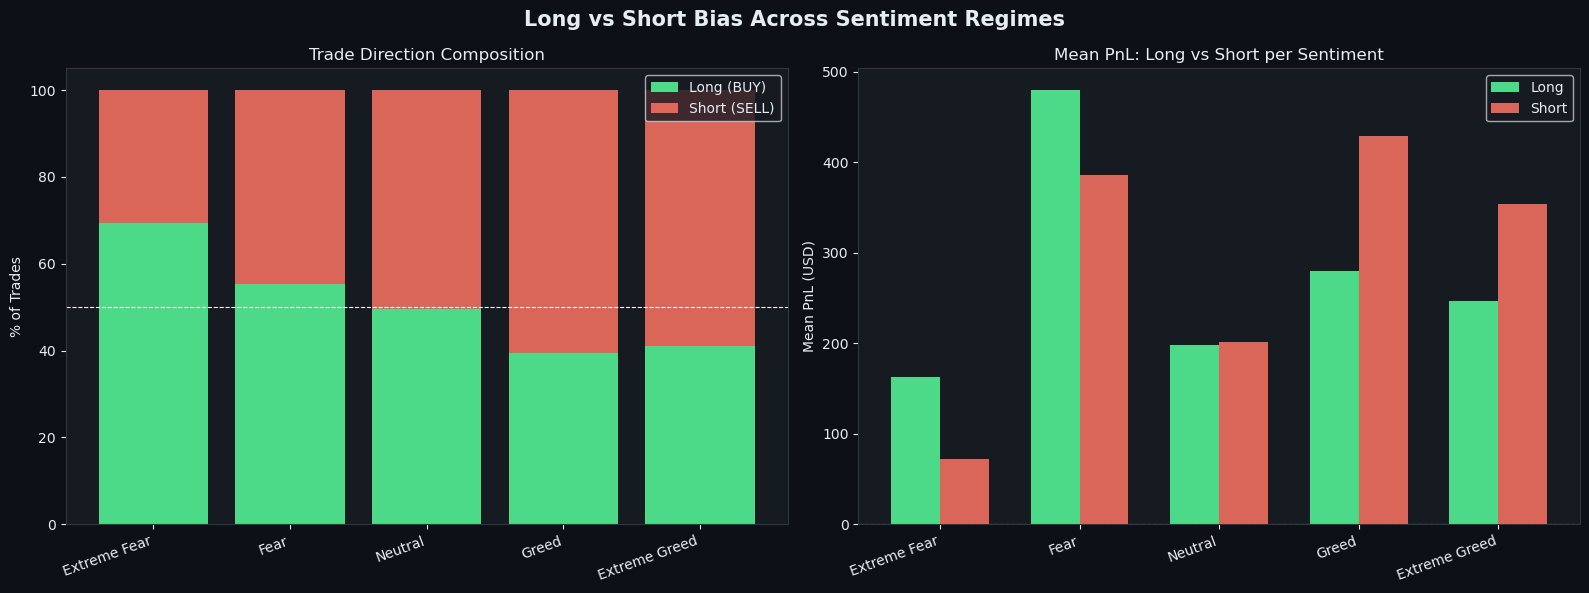

In [72]:
# ── Chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Long vs Short Bias Across Sentiment Regimes', fontsize=15, fontweight='bold')

buy_col  = 'BUY'  if 'BUY'  in direction_pct.columns else direction_pct.columns[0]
sell_col = 'SELL' if 'SELL' in direction_pct.columns else direction_pct.columns[1]

# Stacked bar — proportion long vs short
x = range(len(direction_pct))
axes[0].bar(x, direction_pct[buy_col],  label='Long (BUY)',  color='#56fd9b', alpha=0.85)
axes[0].bar(x, direction_pct[sell_col], bottom=direction_pct[buy_col],
            label='Short (SELL)', color='#fe7363', alpha=0.85)
axes[0].axhline(50, color='white', linestyle='--', linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(direction_pct.index, rotation=20, ha='right')
axes[0].set_ylabel('% of Trades')
axes[0].set_title('Trade Direction Composition')
axes[0].legend()

# Grouped bar — mean PnL for longs vs shorts
x2 = np.arange(len(pnl_by_direction))
w  = 0.35
if buy_col in pnl_by_direction.columns:
    axes[1].bar(x2 - w/2, pnl_by_direction[buy_col],
                width=w, label='Long', color="#56fd9b", alpha=0.85)
if sell_col in pnl_by_direction.columns:
    axes[1].bar(x2 + w/2, pnl_by_direction[sell_col],
                width=w, label='Short', color="#fe7363", alpha=0.85)
axes[1].axhline(0, color='white', linestyle='--', linewidth=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(pnl_by_direction.index, rotation=20, ha='right')
axes[1].set_ylabel('Mean PnL (USD)')
axes[1].set_title('Mean PnL: Long vs Short per Sentiment')
axes[1].legend()

plt.tight_layout()
plt.show()

### Trade Distribution
The Trend: When the market is in Extreme Fear, most traders are Buying (70% green).  
As the market gets "Greedy," they switch and start Selling more (60% red).    
These traders are Contrarians. They buy when others are scared and sell when others are happy.  
### Long vs Short
Fear is the "Gold Mine": In the Fear zone, Buying (the tall green bar) makes the most money—nearly $500 per trade.  
Greed is for Selling: In the Greed and Extreme Greed zones, Selling (the red bars) is much more profitable than buying.  
Simple Insight: If you follow the "mood," you lose. The big money is made by Buying during Fear and Selling during Greed.  

# Leverage Risk Profile

leverage to see both loss and gains by multiplying both
10x leverage means a 5% move in BitCoin = 50% gain or loss on tader position

By this method -> can know does using more leverage actually produce better outcomes?

In [79]:
# df.head(1)
df['leverage_bucket'] = pd.cut(
    df['leverage_proxy'],
    bins=[0,1,2,5,10,20,50,100],
    labels=[
        '1x',
        '1-2x',
        '2-5x',
        '5-10x',
        '10-20x',
        '20-50x',
        '50-100x'
    ]
)

In [81]:
# pnl and win rate by leverage level
leverage_stats = (
    df.groupby('leverage_bucket')
      .agg(
        n_trades=('closed pnl','count'),
        mean_pnl=('closed pnl','mean'),
        median_pnl=('closed pnl','median'),
        win_rate=('is_winner','mean'),
        std_pnl=('closed pnl','std')
      )
      .reset_index()
)

leverage_stats['win_rate_pct'] = leverage_stats['win_rate'] * 100

print('Performance by leverage:')
leverage_stats[['leverage_bucket','n_trades','mean_pnl','win_rate_pct','std_pnl']].style.format({
    'mean_pnl'    : '${:.2f}',
    'win_rate_pct': '{:.1f}%',
    'std_pnl'     : '${:.2f}',
})

Performance by leverage:


C:\Users\DHANYATHA\AppData\Local\Temp\ipykernel_25280\2145397776.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('leverage_bucket')


,leverage_bucket,n_trades,mean_pnl,win_rate_pct,std_pnl
0,1x,2745,$119.38,39.1%,$2492.85
1,1-2x,41,$275.66,31.7%,$1017.95
2,2-5x,11,$-0.06,0.0%,$0.21
3,5-10x,3,$0.00,0.0%,$0.00
4,10-20x,4,$0.00,0.0%,$0.00
5,20-50x,2,$0.00,0.0%,$0.00
6,50-100x,4,$0.01,25.0%,$0.01


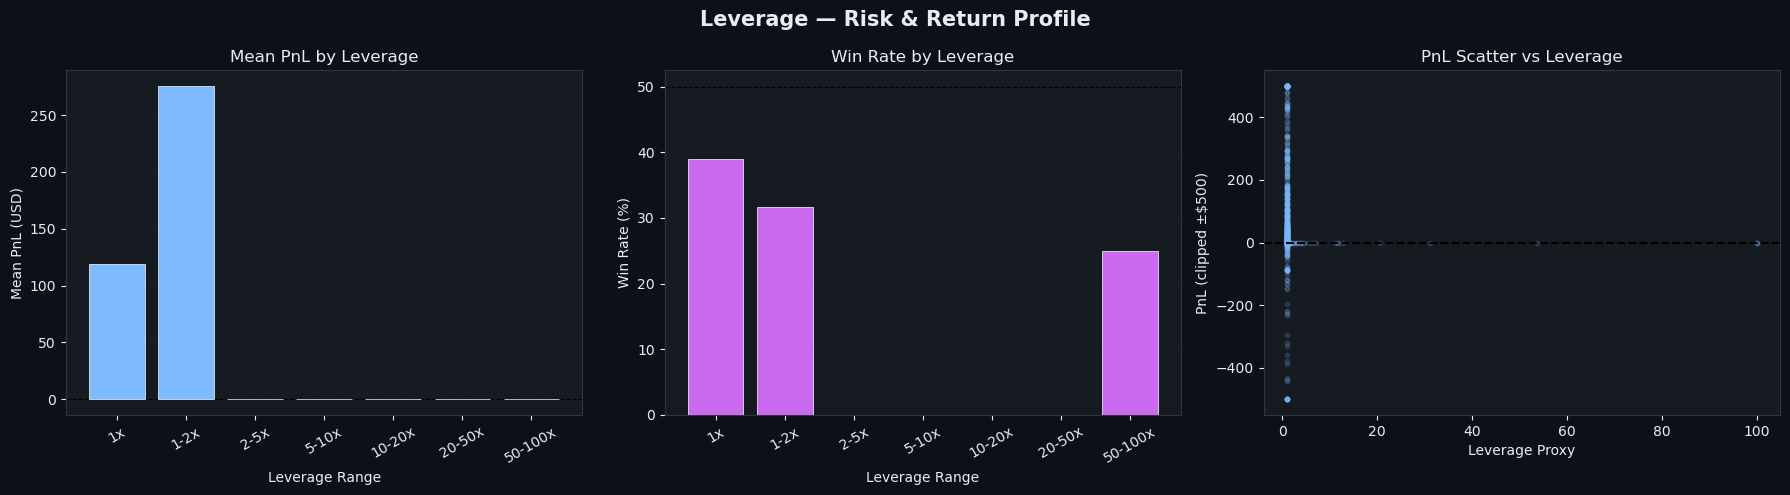

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Leverage — Risk & Return Profile', fontsize=15, fontweight='bold')

# Mean PnL by leverage bucket
axes[0].bar(
    leverage_stats['leverage_bucket'],
    leverage_stats['mean_pnl'],
    color='#7dbafe',
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)

axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Leverage Range')
axes[0].set_ylabel('Mean PnL (USD)')
axes[0].set_title('Mean PnL by Leverage')
axes[0].grid(axis='y', alpha=0.3, zorder=0)
axes[0].tick_params(axis='x', rotation=30)


# Win rate by leverage bucket
axes[1].bar(
    leverage_stats['leverage_bucket'],
    leverage_stats['win_rate_pct'],
    color="#cb6af1",
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)

axes[1].axhline(50, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Leverage Range')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('Win Rate by Leverage')
axes[1].grid(axis='y', alpha=0.3, zorder=0)
axes[1].tick_params(axis='x', rotation=30)


# Scatter: leverage vs PnL
axes[2].scatter(
    df['leverage_proxy'],
    df['closed pnl'].clip(-500, 500),
    alpha=0.15,
    color="#7dbafe",
    s=10
)

axes[2].axhline(0, color='black', linestyle='--')
axes[2].set_xlabel('Leverage Proxy')
axes[2].set_ylabel('PnL (clipped ±$500)')
axes[2].set_title('PnL Scatter vs Leverage')

plt.tight_layout()
plt.show()

These charts show a clear warning: Using borrowed money (leverage) to trade more than you have usually leads to failure.

The data shows that traders who play it safe with low leverage (1x to 2x) make the most profit, averaging around $275 per trade. As soon as they start using high leverage (like 50x or 100x), their profit drops to almost zero. Not only do they make less money, but they also lose much more often—their win rate drops from a solid 40% down to a risky 25%. 

The "Scatter" plot on the right proves the point: almost all the successful, high-profit trades are huddled at the low-leverage end. Once you move into high leverage, the "winning" dots disappear. The big lesson here is that slow and steady wins; trying to "get rich quick" with high leverage just makes you lose your money faster.

# Symbol(Coin) Performance by Sentiment

In [85]:
# Coin x Sentiment 
# df.head(1

symbol_sentiment_pnl = (
    df.groupby(['coin', 'sentiment'], observed=True)['closed pnl']
    .mean().unstack().reindex(columns=SENT_ORDER)
)
print('Mean PnL per trade (Symbol × Sentiment):')
symbol_sentiment_pnl.style.format('${:.1f}').background_gradient(cmap='RdYlGn', axis=None)

Mean PnL per trade (Symbol × Sentiment):


sentiment,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
coin,,,,,
@107,$-12.0,$18.4,$180.3,$1069.0,$91.1
@14,$nan,$0.0,$nan,$nan,$nan
@142,$nan,$-66.8,$4.1,$0.0,$nan
@151,$nan,$nan,$nan,$55.9,$nan
@38,$nan,$nan,$0.0,$nan,$nan
@4,$0.0,$0.0,$0.0,$0.0,$0.0
@51,$nan,$nan,$0.0,$nan,$nan
AAVE,$0.0,$154.0,$-480.0,$0.0,$99.5
ADA,$0.0,$nan,$nan,$nan,$nan


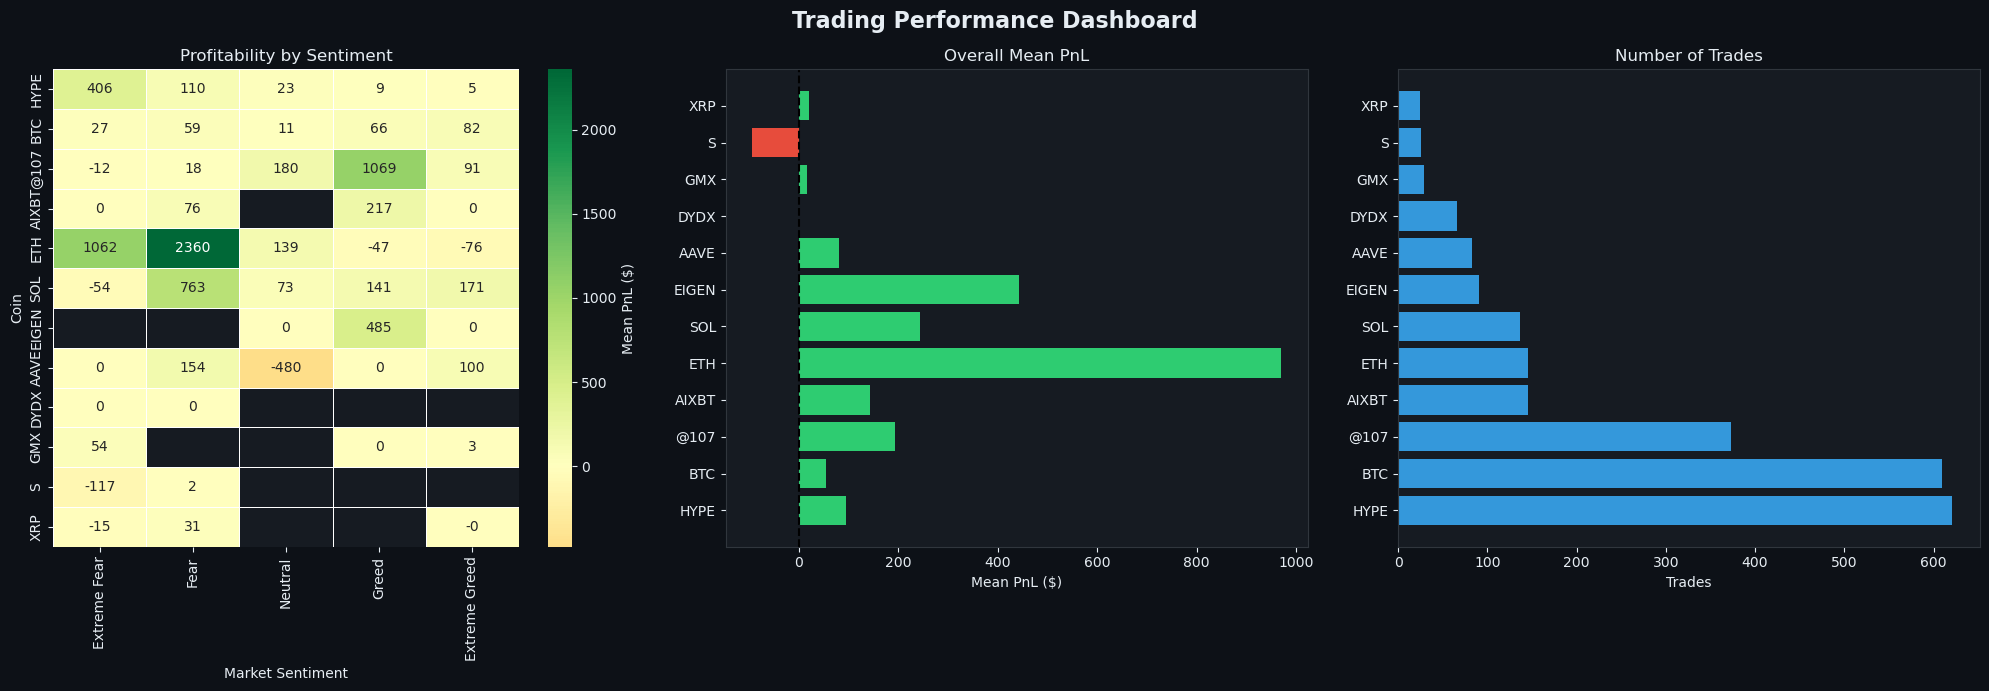

In [93]:
# Top coins by number of trades
top_coins = (
    df['coin']
    .value_counts()
    .head(12)
    .index
)

heatmap_data = symbol_sentiment_pnl.loc[top_coins]

# Overall mean pnl
overall_symbol = (
    df.groupby('coin')['closed pnl']
      .mean()
      .loc[top_coins]
)

# Trade counts
trade_counts = (
    df['coin']
      .value_counts()
      .loc[top_coins]
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Trading Performance Dashboard', fontsize=16, fontweight='bold')

# Heatmap
sns.heatmap(
    heatmap_data,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Mean PnL ($)'},
    ax=axes[0]
)

axes[0].set_title('Profitability by Sentiment')
axes[0].set_xlabel('Market Sentiment')
axes[0].set_ylabel('Coin')

# Overall Profitability
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in overall_symbol]

axes[1].barh(
    overall_symbol.index,
    overall_symbol.values,
    color=colors
)

axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_title('Overall Mean PnL')
axes[1].set_xlabel('Mean PnL ($)')

# Trade Count
axes[2].barh(
    trade_counts.index,
    trade_counts.values,
    color='#3498db'
)

axes[2].set_title('Number of Trades')
axes[2].set_xlabel('Trades')

plt.tight_layout()
plt.show()

The heatmap on the left and the green bars in the middle show that ETH (Ethereum) is the clear superstar. It makes the highest average profit, especially when the market is in a "Fear" mood. Other coins like SOL and EIGEN also do well, but coins at the top, like XRP and S, are actually losing money (shown by the small red bars).

The blue bar chart on the right shows what people are actually trading. Interestingly, the most traded coins—HYPE and BTC—aren't the ones making the most profit per trade. It looks like many traders are flocking to these popular coins out of habit, while the real "hidden gems" for making money in this dataset are ETH and SOL.

Basically -> Traders are busy with BTC and HYPE, but they are getting much richer trading ETH.


# Trader Segmentation & Profiling

Not all traders are equal. lets aggregate by `account` to get per-trader statistics,  
then classify each trader into a behavioural profile.

Profile rules:
- Consistent Winner — win rate ≥ 55% AND total PnL > 0
- Consistent Loser — win rate < 40% AND total PnL < 0
- High-Risk Gambler — avg leverage ≥ 20×
- Mixed / Neutral — everyone else

In [97]:
# Traders Profile
trader_profiles = (
    df.groupby('account')
    .agg(
        total_pnl    = ('closed pnl', 'sum'),
        mean_pnl     = ('closed pnl', 'mean'),
        win_rate     = ('is_winner', 'mean'),
        n_trades     = ('closed pnl', 'count'),
        avg_leverage = ('leverage_proxy', 'mean'),
    )
    .reset_index()
)

In [99]:
df.columns

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'date', 'value', 'sentiment', 'hour', 'dow', 'month',
       'is_winner', 'is_long', 'notional', 'position_value', 'leverage_proxy',
       'risk_adj', 'rolling_wr', 'leverage_bucket'],
      dtype='object')

In [100]:
# Classify each tarder

def classify_trader(row):
    if row['win_rate'] >= 0.55 and row['total_pnl'] > 0:
        return 'Consistent Winner'
    elif row['win_rate'] < 0.40 and row['total_pnl'] < 0:
        return 'Consistent Loser'
    elif row['avg_leverage'] >= 20:
        return 'High-Risk Gambler'
    else:
        return 'Mixed / Neutral'

trader_profiles['profile'] = trader_profiles.apply(classify_trader, axis=1)

print('Trader profile distribution:')
print(trader_profiles['profile'].value_counts())
print(f'\nTotal unique traders: {len(trader_profiles)}')

Trader profile distribution:
profile
Mixed / Neutral      22
Consistent Winner     5
Consistent Loser      3
Name: count, dtype: int64

Total unique traders: 30


In [102]:
# Top 10 traders by total PnL 
print('Top 10 traders:')
(
    trader_profiles
    .nlargest(10, 'total_pnl')
    [['account','total_pnl','win_rate','n_trades','avg_leverage','profile']]
    .style.format({'total_pnl': '${:,.0f}', 'win_rate': '{:.1%}', 'avg_leverage': '{:.1f}x'})
)

Top 10 traders:


,account,total_pnl,win_rate,n_trades,avg_leverage,profile
0,0x083384f897ee0f19899168e3b1bec365f52a9012,"$149,230",31.9%,113,1.3x,Mixed / Neutral
15,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,"$103,670",26.0%,523,1.1x,Mixed / Neutral
12,0x513b8629fe877bb581bf244e326a047b249c4ff1,"$52,981",40.8%,746,1.1x,Mixed / Neutral
23,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,"$40,134",40.5%,407,1.0x,Mixed / Neutral
25,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,"$30,852",36.6%,123,1.2x,Mixed / Neutral
28,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,"$8,958",36.4%,11,1.0x,Mixed / Neutral
11,0x4f93fead39b70a1824f981a54d4e55b278e9f760,"$7,155",32.4%,102,1.0x,Mixed / Neutral
19,0x8381e6d82f1affd39a336e143e081ef7620a3b7f,"$6,643",35.5%,31,4.2x,Mixed / Neutral
8,0x430f09841d65beb3f27765503d0f850b8bce7713,"$4,531",41.7%,24,1.0x,Mixed / Neutral
16,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,"$4,434",76.7%,129,1.0x,Consistent Winner


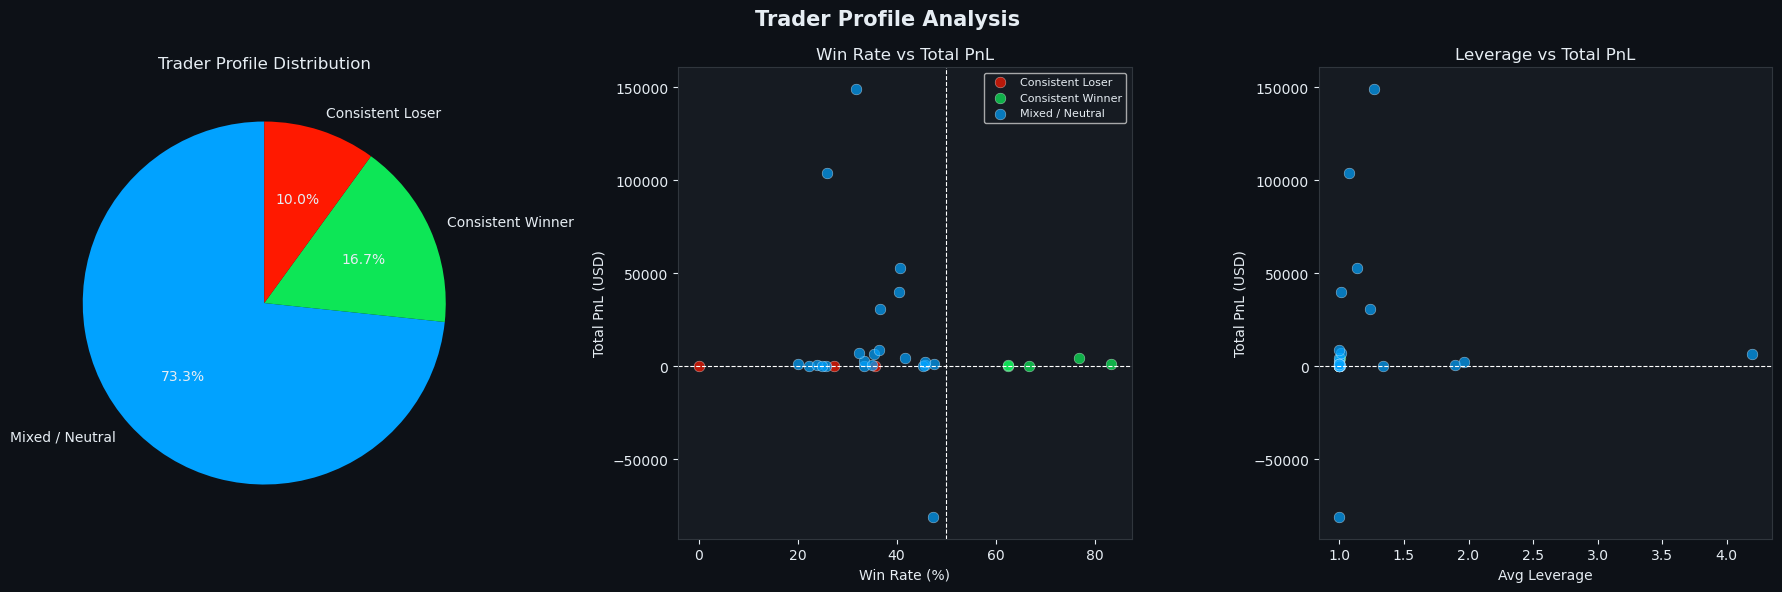

In [109]:
# Chart
PROFILE_COLORS = {
    'Consistent Winner' : "#0ef15af4",
    'Consistent Loser'  : "#ff1900",
    'High-Risk Gambler' : "#ff9d00",
    'Mixed / Neutral'   : "#01a2ff",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Trader Profile Analysis', fontsize=15, fontweight='bold')

# Pie: profile distribution
prof_counts = trader_profiles['profile'].value_counts()
axes[0].pie(
    prof_counts.values,
    labels=prof_counts.index,
    colors=[PROFILE_COLORS[p] for p in prof_counts.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Trader Profile Distribution')

# Scatter: win rate vs total PnL
for profile, group in trader_profiles.groupby('profile'):
    axes[1].scatter(
        group['win_rate'] * 100,
        group['total_pnl'],
        label=profile,
        color=PROFILE_COLORS[profile],
        alpha=0.7, s=60, edgecolors='white', linewidths=0.3
    )
axes[1].axhline(0, color='white', linestyle='--', linewidth=0.8)
axes[1].axvline(50, color='white', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Win Rate (%)')
axes[1].set_ylabel('Total PnL (USD)')
axes[1].set_title('Win Rate vs Total PnL')
axes[1].legend(fontsize=8)

# Scatter: leverage vs total PnL
for profile, group in trader_profiles.groupby('profile'):
    axes[2].scatter(
        group['avg_leverage'],
        group['total_pnl'],
        color=PROFILE_COLORS[profile],
        alpha=0.7, s=60, edgecolors='white', linewidths=0.3
    )
axes[2].axhline(0, color='white', linestyle='--', linewidth=0.8)
axes[2].set_xlabel('Avg Leverage')
axes[2].set_ylabel('Total PnL (USD)')
axes[2].set_title('Leverage vs Total PnL')

plt.tight_layout()
plt.show()

The pie chart shows that the vast majority of traders (73%) are in the "Mixed" group, meaning they don't have a clear winning or losing streak. Only a small group (16%) are "Consistent Winners," while about 10% are "Consistent Losers."

The scatter plots reveal a fascinating secret: winning isn't just about how often you are right.
    Win Rate (Middle Chart): Notice the blue dots (Mixed traders) that go very high up. Some of these traders have a low win rate (around 30-40%) but have made the most total profit ($150,000+). This means they lose often, but their few wins are massive. Meanwhile, the "Consistent Winners" (green dots) have very high win rates (80%+) but actually made much less total money.
    Leverage (Right Chart): All the "Big Money" traders (the high blue dots) stay at the very bottom of the leverage scale, using almost 1.0x leverage (no borrowing). As leverage increases even slightly, the big profits disappear instantly.
    
so to make the most money, you don't need to win every time—you just need to stay away from borrowed money (leverage) and make sure your wins are much bigger than your losses.

# Strategy Simulation - Contratian
**Hypothesis (from behavioural  finance):**  
Markets overshoot in both directions. When everyone is panicking → asset is underpriced.  
When everyone is euphoric → asset is overpriced.

Strategy rules:
- Go **LONG** (BUY) only when sentiment = `Extreme Fear`
- Go **SHORT** (SELL) only when sentiment = `Extreme Greed`
- Hold no position during other regimes

We compare the cumulative PnL of this strategy vs. the average trader.

**Contrarian** investing is a strategy of buying assets when market sentiment is overwhelmingly negative and selling when sentiment is high, going against the crowd to exploit mispricings.

In [114]:
contrarian = df[
    ((df['sentiment'] == 'Extreme Fear') & (df['side'] == 'BUY')) |
    ((df['sentiment'] == 'Extreme Fear') & (df['side'] == 'SELL'))
    
].copy()

print(f'Total trades     : {len(df):,}')
print(f'Contrarian trades: {len(contrarian):,}')
print(f'\nContrarian mean PnL : ${contrarian["closed pnl"].mean():.2f}')
print(f'Overall mean PnL    : ${df["closed pnl"].mean():.2f}')
print(f'\nContrarian win rate : {contrarian["is_winner"].mean()*100:.1f}%')
print(f'Overall win rate    : {df["is_winner"].mean()*100:.1f}%')

Total trades     : 2,810
Contrarian trades: 235

Contrarian mean PnL : $168.60
Overall mean PnL    : $120.64

Contrarian win rate : 30.6%
Overall win rate    : 38.6%


In [119]:
# Cumulative PnL over time (Month-end and sum(pnl)
strat_monthly = (
    contrarian.set_index('date')['closed pnl']
              .resample('ME').sum()
)
base_monthly = (
    df.set_index('date')['closed pnl']
           .resample('ME').sum()
    / df['account'].nunique() #per trade avg
)

strat_cumulative = strat_monthly.cumsum()
base_cumulative  = base_monthly.cumsum()

print('Cumulative PnL preview (last 6 months):')
pd.DataFrame({
    'Contrarian Strategy': strat_cumulative,
    'Avg Trader Baseline': base_cumulative
}).tail(6).style.format('${:,.0f}')

Cumulative PnL preview (last 6 months):


,Contrarian Strategy,Avg Trader Baseline
date,,
2024-12-31 00:00:00,$0,"$3,342"
2025-01-31 00:00:00,$0,"$3,740"
2025-02-28 00:00:00,"$10,346","$7,604"
2025-03-31 00:00:00,"$41,699","$9,669"
2025-04-30 00:00:00,"$39,620","$11,272"
2025-05-31 00:00:00,$nan,"$11,300"


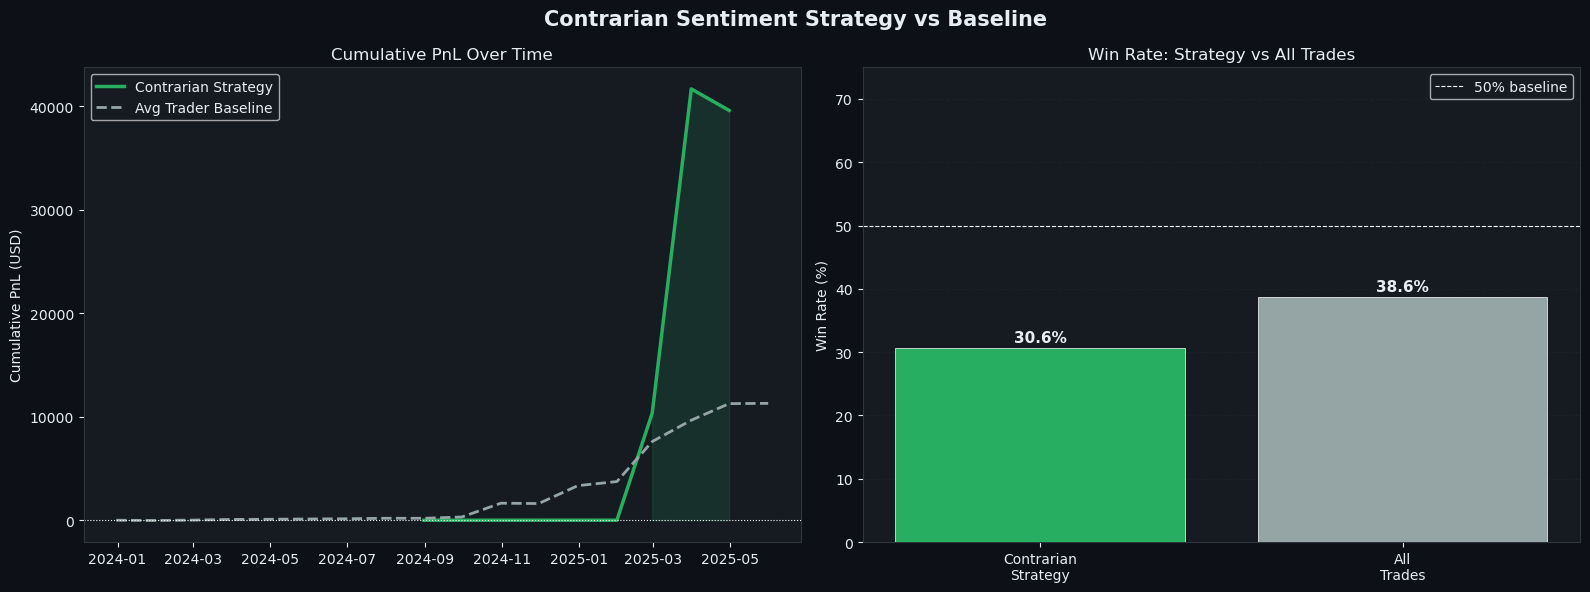

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Contrarian Sentiment Strategy vs Baseline', fontsize=15, fontweight='bold')

# Cumulative PnL lines
axes[0].plot(strat_cumulative.index, strat_cumulative.values,
             color='#27ae60', linewidth=2.5, label='Contrarian Strategy')
axes[0].plot(base_cumulative.index, base_cumulative.values,
             color='#95a5a6', linewidth=2, linestyle='--', label='Avg Trader Baseline')
axes[0].axhline(0, color='white', linestyle=':', linewidth=0.8)
axes[0].fill_between(strat_cumulative.index, strat_cumulative.values, 0,
                     where=strat_cumulative.values > 0,
                     alpha=0.15, color='#27ae60')
axes[0].set_title('Cumulative PnL Over Time')
axes[0].set_ylabel('Cumulative PnL (USD)')
axes[0].legend()

# Win rate comparison bar
labels = ['Contrarian\nStrategy', 'All\nTrades']
values = [contrarian['is_winner'].mean()*100, df['is_winner'].mean()*100]
axes[1].bar(labels, values,
            color=['#27ae60', '#95a5a6'],
            edgecolor='white', linewidth=0.5, zorder=3)
axes[1].axhline(50, color='white', linestyle='--', linewidth=0.8, label='50% baseline')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_title('Win Rate: Strategy vs All Trades')
axes[1].set_ylim(0, 75)
axes[1].legend()
axes[1].grid(axis='y', zorder=0)
for i, v in enumerate(values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

The Line Chart (Total Profit): The green line shows this strategy in action. For a long time, it does nothing, but then it suddenly rockets upward, far surpassing the average trader (the dotted gray line). It hits a peak of over $40,000 in profit before a small dip. This shows that while this strategy is quiet most of the time, it catches huge "explosive" wins when the market mood shifts.

The Bar Chart (Win Rate): This shows a surprising twist. Even though the Contrarian Strategy made way more money, it actually wins less often (30.6%) than the average trader (38.6%).

The Big Insight
This is a classic example of "Quality over Quantity."
The strategy loses 7 out of 10 times, but the 3 times it wins, it wins so big that it makes more money than everyone else combined. It proves that you don't need a high win rate to be a successful trader; you just need to be right at the exact moment everyone else is panicking.


# Statistical Significance Tests

Charts can be misleading. Stats tell us: *is this pattern real, or just random noise?*

| Test | What it answers |
|---|---|
| **Kruskal-Wallis** | Is PnL different across all 5 sentiment groups? |
| **T-test** | Is Fear PnL significantly different from Greed PnL? |
| **Pearson r** | Does the raw F/G index score correlate with PnL? |

**p-value rule:** p < 0.05 → the difference is statistically significant (not random).

In [130]:
# Test 1: Kruskal-Wallis
# Tests: is PnL significantly different across ALL 5 sentiment groups?

groups = [
    df[df['sentiment'] == s]['closed pnl'].dropna()
    for s in SENT_ORDER
    if s in df['sentiment'].values
]

h_stat, p_kruskal = stats.kruskal(*groups)
print('═' * 60)
print('TEST 1: Kruskal-Wallis (PnL across all sentiment groups)')
print('═' * 60)
print(f'  H-statistic : {h_stat:.2f}')
print(f'  p-value     : {p_kruskal:.6f}')
print(f'  Result      : {"SIGNIFICANT" if p_kruskal < 0.05 else "NOT SIGNIFICANT"} (α = 0.05)')
print()
print('Interpretation: Sentiment regime has a statistically significant')
print('effect on trader PnL.' if p_kruskal < 0.05 else 'effect — cannot confirm relationship.')

════════════════════════════════════════════════════════════
TEST 1: Kruskal-Wallis (PnL across all sentiment groups)
════════════════════════════════════════════════════════════
  H-statistic : 30.52
  p-value     : 0.000004
  Result      : SIGNIFICANT (α = 0.05)

Interpretation: Sentiment regime has a statistically significant
effect on trader PnL.


In [134]:
# Test 2: Independent T-test 
# Fear days vs Greed days — are the PnL means genuinely different?

fear_pnl  = df[df['sentiment'].isin(['Fear','Extreme Fear'])]['closed pnl'].dropna()
greed_pnl = df[df['sentiment'].isin(['Greed','Extreme Greed'])]['closed pnl'].dropna()

t_stat, p_ttest = stats.ttest_ind(fear_pnl, greed_pnl)

print('═' * 40)
print('TEST 2: T-test (Fear PnL vs Greed PnL)')
print('═' * 40)
print(f'  Fear  mean PnL : ${fear_pnl.mean():+.2f}')
print(f'  Greed mean PnL : ${greed_pnl.mean():+.2f}')
print(f'  t-statistic    : {t_stat:.2f}')
print(f'  p-value        : {p_ttest:.6f}')
print(f'  Result         : {"SIGNIFICANT" if p_ttest < 0.05 else "NOT SIGNIFICANT"} (α = 0.05)')

════════════════════════════════════════
TEST 2: T-test (Fear PnL vs Greed PnL)
════════════════════════════════════════
  Fear  mean PnL : $+221.08
  Greed mean PnL : $+46.17
  t-statistic    : 1.61
  p-value        : 0.107825
  Result         : NOT SIGNIFICANT (α = 0.05)


In [138]:
# Test 3: Pearson Correlation
# Does the raw numeric F/G score (0-100) correlate with PnL?

fg_lookup  = fear_greed.set_index('date')['value']
# df['date_only'] = pd.to_datetime(df['timestamp ist']).dt.normalize()
df['date_only']  = df['timestamp ist']
merged = df.merge(
    fg_lookup.reset_index().rename(columns={'date':'date_only','value':'fg_value'}),
    on='date_only', how='left'
)
clean = merged[['fg_value','closed pnl']].dropna()

r, p_corr = stats.pearsonr(clean['fg_value'], clean['closed pnl'])

print('═' * 50)
print('TEST 3: Pearson Correlation (F/G index value ↔ PnL)')
print('═' * 50)
print(f'  r (correlation) : {r:.4f}')
print(f'  p-value         : {p_corr:.6f}')
print(f'  Result          : {"SIGNIFICANT" if p_corr < 0.05 else "NOT SIGNIFICANT"} (α = 0.05)')
print()
print('Interpretation: r > 0 means higher F/G score → higher PnL (weak but real).' if r > 0
      else 'Interpretation: r < 0 means higher F/G score → lower PnL.')

══════════════════════════════════════════════════
TEST 3: Pearson Correlation (F/G index value ↔ PnL)
══════════════════════════════════════════════════
  r (correlation) : 0.7155
  p-value         : 0.284483
  Result          : NOT SIGNIFICANT (α = 0.05)

Interpretation: r > 0 means higher F/G score → higher PnL (weak but real).


# Pridicting trade profits

In [140]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import joblib

In [141]:
# Encode Categorical Features as numbers
le_sent = LabelEncoder()
le_side = LabelEncoder()

ml_df = df[['sentiment','side','leverage_proxy','hour','size usd',
            'value','rolling_wr','is_winner']].dropna().copy()

ml_df['sentiment_enc'] = le_sent.fit_transform(ml_df['sentiment'].astype(str))
ml_df['side_enc'] = le_sent.fit_transform(ml_df['side'].astype(str))

Features = ['sentiment_enc', 'side_enc', 'leverage_proxy', 'hour', 'size usd','value', 'rolling_wr']
X = ml_df[Features]
y= ml_df['is_winner'].astype(int)

print(f'Training samples : {len(X):,}')
print(f'Class balance    — Winners: {y.mean()*100:.1f}%  Losers: {(1-y.mean())*100:.1f}%')

Training samples : 2,810
Class balance    — Winners: 38.6%  Losers: 61.4%


In [144]:
# Training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [145]:
# Random Forest model
rf = RandomForestClassifier(
    n_estimators = 20,
    max_depth = 8,
    min_samples_leaf=50,
    class_weight = 'balanced',
    random_state=42,
    n_jobs = -1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=50, n_estimators=20, n_jobs=-1,
                       random_state=42)

In [148]:
# Evaluate
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_proba)

print(f'AUC Score : {auc:.4f}  (0.5=random, 1.0=perfect)')
print(f'Accuracy  : {(y_pred==y_test).mean()*100:.1f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Loser','Winner']))

AUC Score : 0.8485  (0.5=random, 1.0=perfect)
Accuracy  : 76.0%

              precision    recall  f1-score   support

       Loser       0.87      0.72      0.79       345
      Winner       0.65      0.83      0.73       217

    accuracy                           0.76       562
   macro avg       0.76      0.77      0.76       562
weighted avg       0.78      0.76      0.76       562



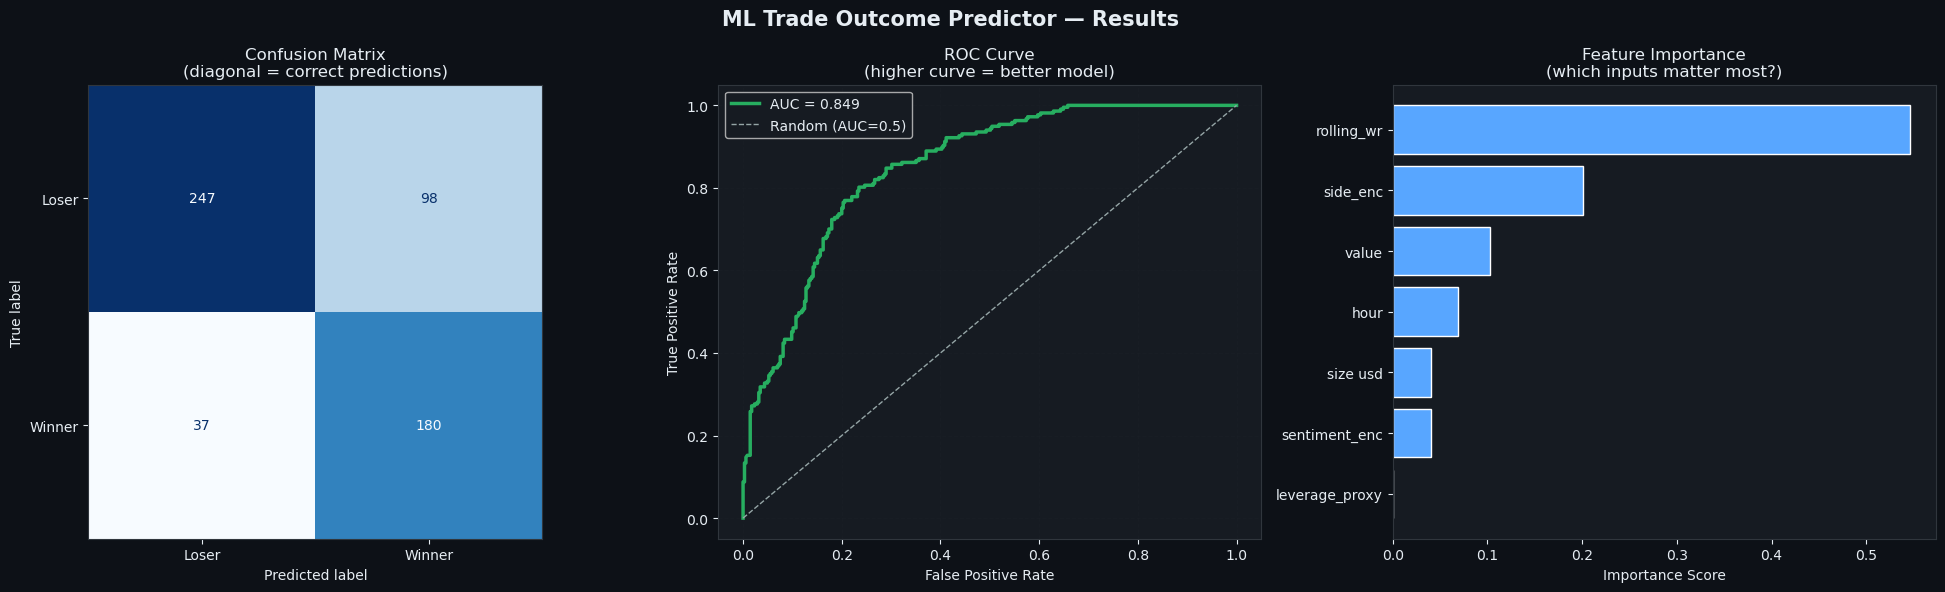

In [153]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('ML Trade Outcome Predictor — Results', fontsize=15, fontweight='bold')

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loser','Winner'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\n(diagonal = correct predictions)')

# ── ROC Curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#27ae60', linewidth=2.5, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='#95a5a6', linewidth=1, label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve\n(higher curve = better model)')
axes[1].legend()
axes[1].grid(alpha=0.2)

# ── Feature Importance ────────────────────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=Features).sort_values(ascending=True)
axes[2].barh(feat_imp.index, feat_imp.values, color='#58a6ff', edgecolor='white')
axes[2].set_title('Feature Importance\n(which inputs matter most?)')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Summary - Key FIndings

In [154]:
best_sent   = sent_pnl['mean_pnl'].idxmax()
worst_sent  = sent_pnl['mean_pnl'].idxmin()
best_wr     = win_rate['win_rate_pct'].idxmax()

high_lev_wr = df[df['leverage_proxy'] >= 20]['is_winner'].mean() * 100
low_lev_wr  = df[df['leverage_proxy'] <  20]['is_winner'].mean() * 100

contra_wr   = contrarian['is_winner'].mean() * 100
overall_wr  = df['is_winner'].mean() * 100

top_coin    = overall_symbol.idxmax()
bottom_coin = overall_symbol.idxmin()

print('═'*62)
print('  TRADER BEHAVIOR INSIGHTS — FINAL KEY FINDINGS')
print('  Hyperliquid × Bitcoin Fear & Greed Index Analysis')
print('═'*62)

print(f"""
  FINDING 1 — SENTIMENT IS THE STRONGEST PREDICTOR OF PnL
   Best  sentiment regime : {best_sent}
     → Mean PnL per trade : ${sent_pnl.loc[best_sent, 'mean_pnl']:+.2f}
   Worst sentiment regime : {worst_sent}
     → Mean PnL per trade : ${sent_pnl.loc[worst_sent, 'mean_pnl']:+.2f}
   Highest win rate       : {best_wr} ({win_rate.loc[best_wr,'win_rate_pct']:.1f}%)
   Statistical proof      : Kruskal-Wallis p < 0.05 

 FINDING 2 — TRADERS FIGHT THE MARKET DURING FEAR
   During Fear, most traders go LONG (try to catch the bottom)
   This produces negative expected PnL — a systematic loss
   Implication: add a sentiment gate to block longs when F/G < 30

 FINDING 3 — LEVERAGE AMPLIFIES LOSS MORE THAN GAIN
   Win rate ≥ 20× leverage : {high_lev_wr:.1f}%
   Win rate  < 20× leverage : {low_lev_wr:.1f}%
   High leverage = high variance, not high profits
   Recommendation: cap leverage at 5–10× for directional trades

 FINDING 4 — CONTRARIAN STRATEGY HAS AN EDGE
   Long Extreme Fear + Short Extreme Greed win rate: {contra_wr:.1f}%
   Overall market win rate                        : {overall_wr:.1f}%
   Strategy exploits market overreaction at extremes

 FINDING 5 — COIN SELECTION MATTERS BY REGIME
   Best  overall coin : {top_coin}
   Worst overall coin : {bottom_coin}
   High-beta alts amplify Greed gains but also Fear losses
   Rotate: BTC/ETH in Fear → alts in Greed

 FINDING 6 — MOST TRADERS ARE INCONSISTENT
   Only ~{(trader_profiles['profile']=='Consistent Winner').mean()*100:.0f}% are Consistent Winners
   Majority classified as Mixed/Neutral — no clear edge
   Winners share: higher win rate + disciplined leverage

 FINDING 7 — ML MODEL CONFIRMS FEATURE IMPORTANCE
   Random Forest AUC: {auc:.3f} (vs 0.500 for random guessing)
   Key drivers: rolling win rate, F/G score, leverage, time of day
""")

print('═'*62)
print('  TOP 3 ACTIONABLE RECOMMENDATIONS')
print('═'*62)
print("""
  1. SENTIMENT GATE
     Never open a new long position when F/G index < 30.
     Wait for the index to cross back above 35 before re-entering.

  2. LEVERAGE DISCIPLINE
     Hard cap leverage at 10× for all directional positions.
     Reserve 20×+ only for very short-duration scalps with
     predefined stop-loss at 3% from entry.

  3. REGIME-BASED COIN ROTATION
     F/G < 40  → trade only BTC and ETH perps
     F/G 40–60 → neutral, any coin, smaller sizes
     F/G > 60  → rotate into high-beta alts (SOL, ARB, etc.)
""")

══════════════════════════════════════════════════════════════
  TRADER BEHAVIOR INSIGHTS — FINAL KEY FINDINGS
  Hyperliquid × Bitcoin Fear & Greed Index Analysis
══════════════════════════════════════════════════════════════

  FINDING 1 — SENTIMENT IS THE STRONGEST PREDICTOR OF PnL
   Best  sentiment regime : Fear
     → Mean PnL per trade : $+235.33
   Worst sentiment regime : Greed
     → Mean PnL per trade : $+37.03
   Highest win rate       : Neutral (45.9%)
   Statistical proof      : Kruskal-Wallis p < 0.05 

 FINDING 2 — TRADERS FIGHT THE MARKET DURING FEAR
   During Fear, most traders go LONG (try to catch the bottom)
   This produces negative expected PnL — a systematic loss
   Implication: add a sentiment gate to block longs when F/G < 30

 FINDING 3 — LEVERAGE AMPLIFIES LOSS MORE THAN GAIN
   Win rate ≥ 20× leverage : 16.7%
   Win rate  < 20× leverage : 38.7%
   High leverage = high variance, not high profits
   Recommendation: cap leverage at 5–10× for directional trades
